In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df.sample(5)

,cgpa,placement_exam_marks,placed
804,6.49,81.0,0
832,6.91,59.0,0
335,6.90,17.0,1
106,6.59,22.0,0
91,7.42,6.0,1


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

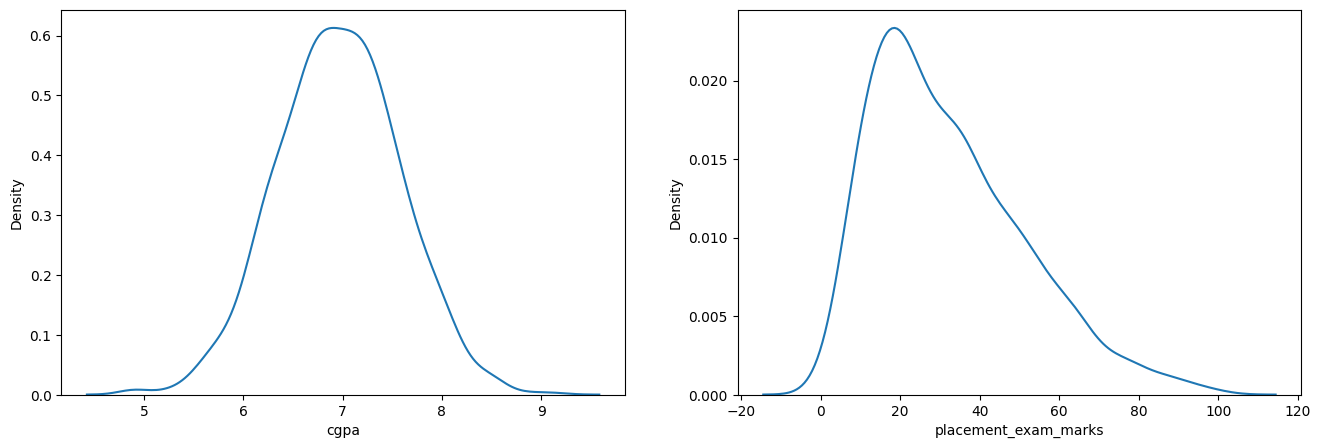

In [4]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(df['cgpa'],ax=ax1)
sns.kdeplot(df['placement_exam_marks'],ax=ax2)

In [5]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

<p>We see the 'placement_exam_marks' is skewed so we can use the IQR method.</p>

In [6]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

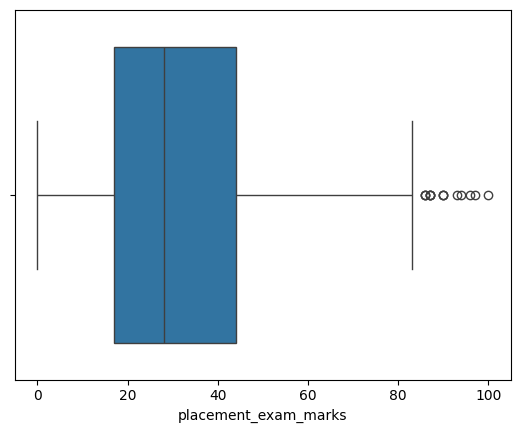

In [10]:
sns.boxplot(x=df['placement_exam_marks'])

<h1>IQR Method</h1>

In [11]:
p25=df['placement_exam_marks'].quantile(0.25)
p75=df['placement_exam_marks'].quantile(0.75)

In [12]:
p25

np.float64(17.0)

In [13]:
p75

np.float64(44.0)

In [14]:
iqr=p75-p25

In [15]:
iqr

np.float64(27.0)

In [16]:
up_lim=p75+1.5*iqr
low_lim=p25-1.5*iqr

In [17]:
up_lim

np.float64(84.5)

In [18]:
low_lim

np.float64(-23.5)

<h3>Finding Outliers</h3>

In [20]:
df[(df['placement_exam_marks']<low_lim)|(df['placement_exam_marks']>up_lim)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


<h3>Trimming</h3>

In [21]:
new_df=df[df['placement_exam_marks']<up_lim]

#as min marks is 0 and low_lim is -23.5, no need to write

In [22]:
new_df.shape

(985, 3)

<h3>Before/After Visualisation</h3>

<Axes: xlabel='placement_exam_marks'>

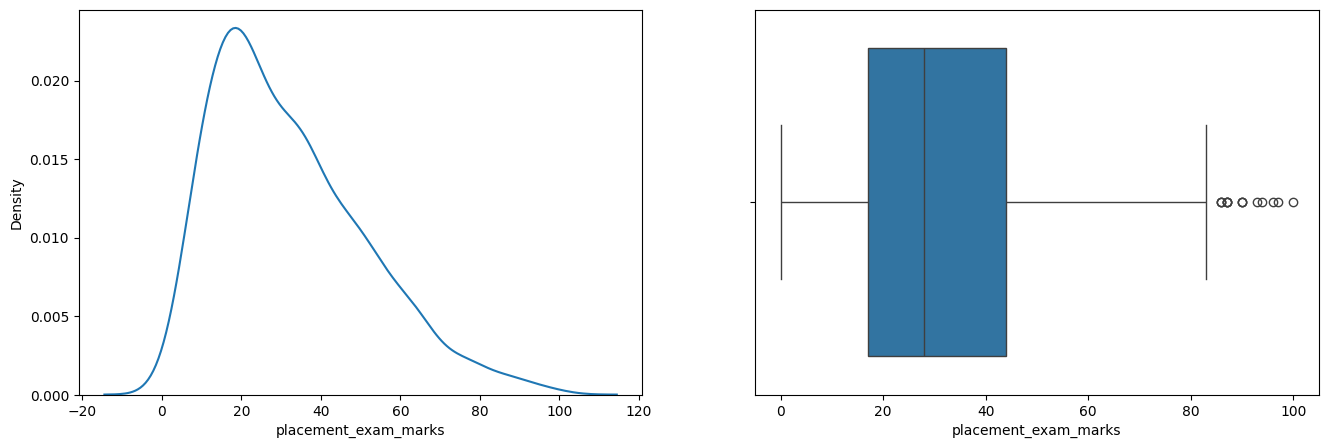

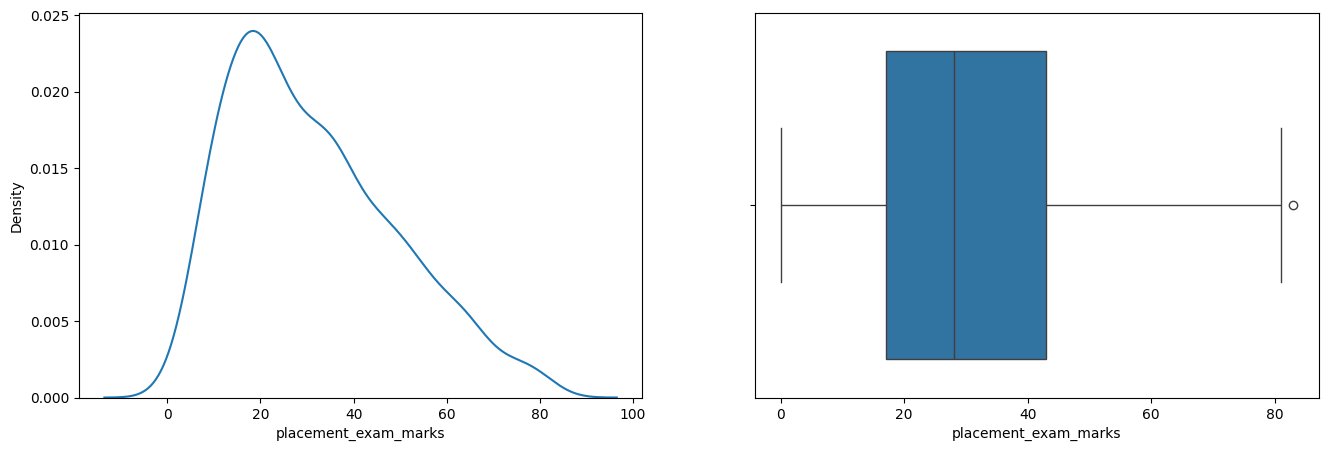

In [27]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(df['placement_exam_marks'],ax=ax1)
sns.boxplot(x=df['placement_exam_marks'],ax=ax2)

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(new_df['placement_exam_marks'],ax=ax1)
sns.boxplot(x=new_df['placement_exam_marks'],ax=ax2)

<p>Slight change in distribution and noticable outlier deduction in boxplot.</p>

<h3>Capping</h3>

In [28]:
new_df_cap=df.copy()

new_df_cap['placement_exam_marks']=np.where(new_df_cap['placement_exam_marks']>up_lim,up_lim,
                                            np.where(new_df_cap['placement_exam_marks']<low_lim,
                                                     low_lim,
                                                     new_df_cap['placement_exam_marks'])
                                           )

In [29]:
new_df_cap.shape

(1000, 3)

<h3>Before/After Visualisation</h3>

<Axes: xlabel='placement_exam_marks'>

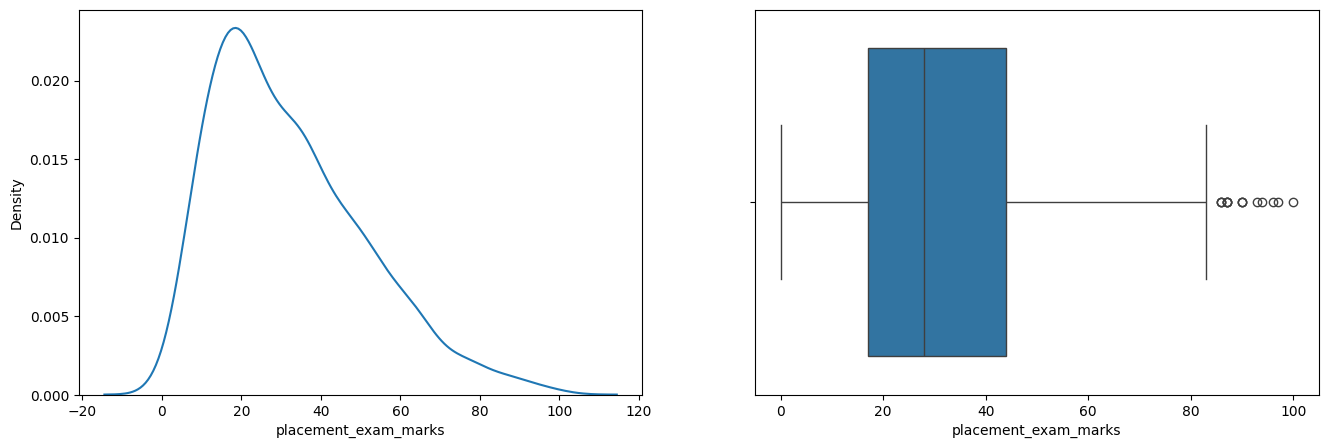

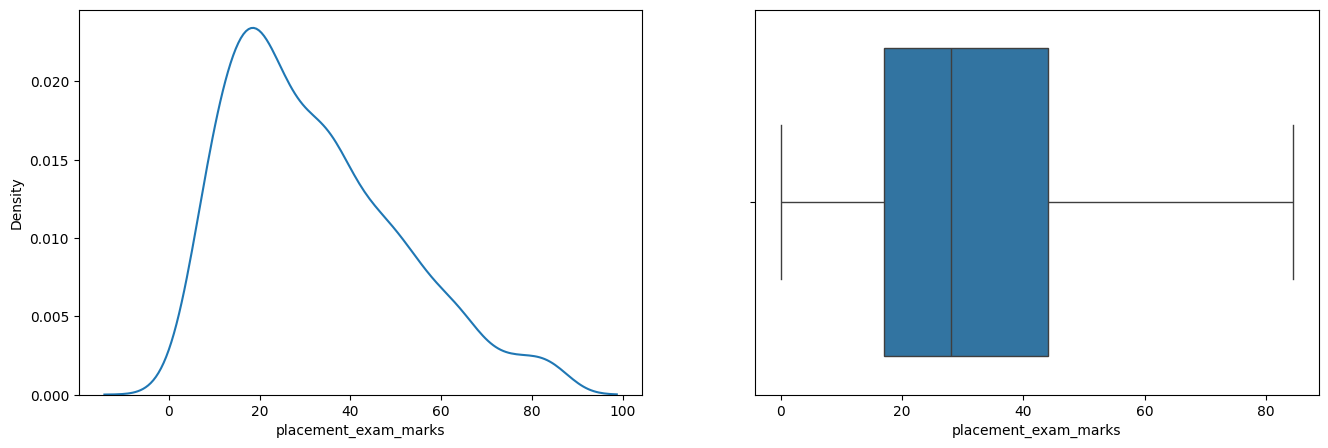

In [30]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(df['placement_exam_marks'],ax=ax1)
sns.boxplot(x=df['placement_exam_marks'],ax=ax2)

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(new_df_cap['placement_exam_marks'],ax=ax1)
sns.boxplot(x=new_df_cap['placement_exam_marks'],ax=ax2)

<p>Slight change in distribution and noticable outlier deduction in boxplot.</p>